<a href="https://colab.research.google.com/github/ShelsyNieves/analisis-ventas-alura/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [5]:
import matplotlib.pyplot as plt

In [6]:
total_tienda1 = (tienda['Precio'] + tienda['Costo de envío']).sum()
total_tienda2 = (tienda2['Precio'] + tienda2['Costo de envío']).sum()
total_tienda3 = (tienda3['Precio'] + tienda3['Costo de envío']).sum()
total_tienda4 = (tienda4['Precio'] + tienda4['Costo de envío']).sum()

In [7]:
totales = [total_tienda1, total_tienda2, total_tienda3, total_tienda4]
nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

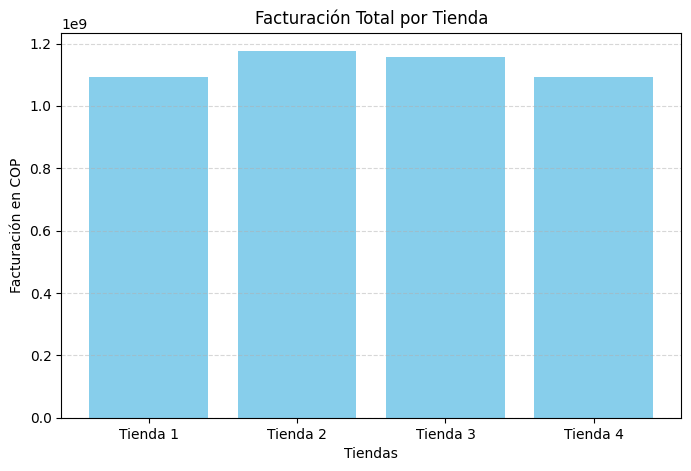

In [8]:
plt.figure(figsize=(8,5))
plt.bar(nombres, totales, color='skyblue')
plt.title('Facturación Total por Tienda')
plt.ylabel('Facturación en COP')
plt.xlabel('Tiendas')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 2. Ventas por categoría

In [9]:
import pandas as pd


In [10]:
datos = pd.concat([tienda, tienda2, tienda3, tienda4])

In [11]:
ventas_categoria = datos['Categoría del Producto'].value_counts()

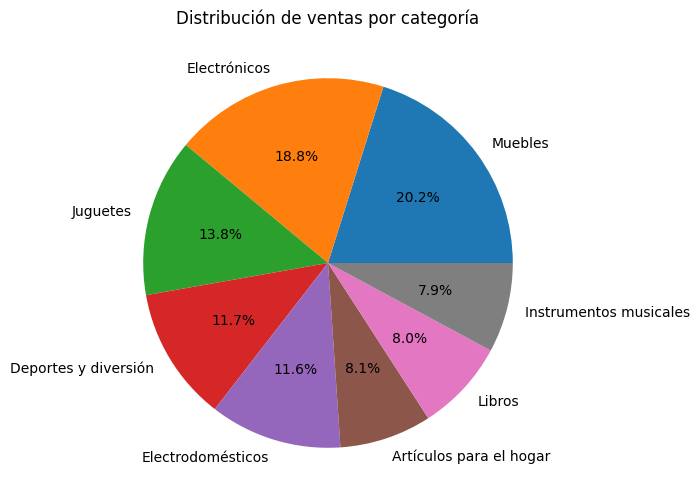

In [12]:
ventas_categoria.plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), title='Distribución de ventas por categoría')
plt.ylabel('')
plt.show()

# 3. Calificación promedio de la tienda


In [13]:
calificaciones = [
    tienda['Calificación'].mean(),
    tienda2['Calificación'].mean(),
    tienda3['Calificación'].mean(),
    tienda4['Calificación'].mean()
]

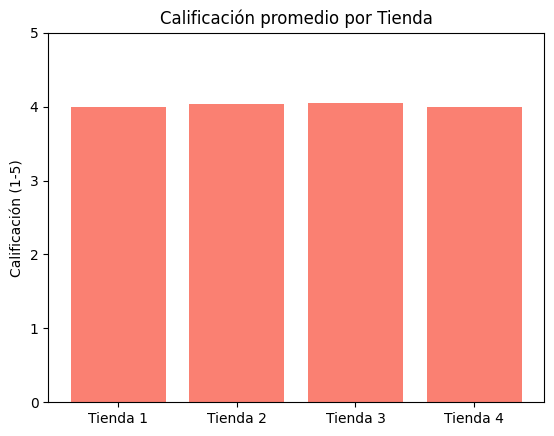

In [14]:
plt.bar(nombres, calificaciones, color='salmon')
plt.title('Calificación promedio por Tienda')
plt.ylim(0, 5)
plt.ylabel('Calificación (1-5)')
plt.show()

# 4. Productos más y menos vendidos

In [15]:
productos_vendidos = datos['Producto'].value_counts()

In [16]:
print("🔝 Productos más vendidos:\n", productos_vendidos.head())
print("\n🔻 Productos menos vendidos:\n", productos_vendidos.tail())

🔝 Productos más vendidos:
 Producto
Cama box                     217
Pandereta                    213
Cama king                    213
Carrito de control remoto    209
Mesa de noche                209
Name: count, dtype: int64

🔻 Productos menos vendidos:
 Producto
TV LED UHD 4K                  167
Mochila                        167
Ciencia de datos con Python    165
Celular ABXY                   163
Guitarra eléctrica             151
Name: count, dtype: int64


# 5. Envío promedio por tienda

In [17]:
envios_prom = [
    tienda['Costo de envío'].mean(),
    tienda2['Costo de envío'].mean(),
    tienda3['Costo de envío'].mean(),
    tienda4['Costo de envío'].mean()
]

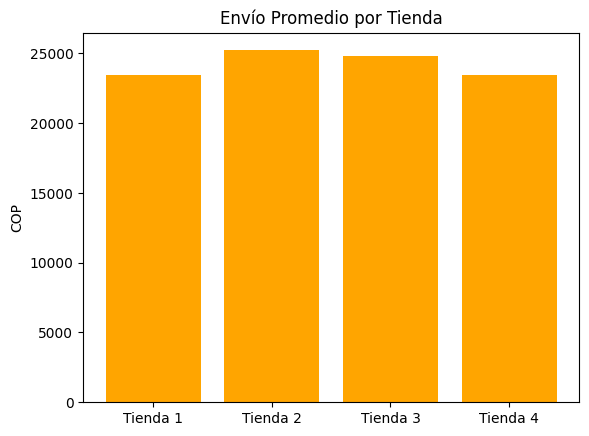

In [18]:
plt.bar(nombres, envios_prom, color='orange')
plt.title('Envío Promedio por Tienda')
plt.ylabel('COP')
plt.show()

In [19]:
def analizar_tienda(tienda_df):
    facturacion = (tienda_df['Precio'] + tienda_df['Costo de envío']).sum()
    calificacion = tienda_df['Calificación'].mean()
    envio_prom = tienda_df['Costo de envío'].mean()
    ventas = len(tienda_df)
    return facturacion, calificacion, envio_prom, ventas

In [20]:
resultados = []

In [21]:
for i, tienda_df in enumerate([tienda, tienda2, tienda3, tienda4], start=1):
    facturacion, calificacion, envio_prom, ventas = analizar_tienda(tienda_df)
    resultados.append({
        'Tienda': f'Tienda {i}',
        'Facturación total': facturacion,
        'Calificación promedio': calificacion,
        'Costo de envío promedio': envio_prom,
        'Cantidad de ventas': ventas
    })


In [22]:
resumen = pd.DataFrame(resultados)
resumen

,Tienda,Facturación total,Calificación promedio,Costo de envío promedio,Cantidad de ventas
0,Tienda 1,1.093693e+09,3.995759,23459.457167,2358
1,Tienda 2,1.175829e+09,4.037304,25216.235693,2359
2,Tienda 3,1.156536e+09,4.048326,24805.680373,2359
3,Tienda 4,1.093693e+09,3.995759,23459.457167,2358


# **Recomendación**

```
## 📌 Recomendación Final

Después de analizar los datos de las 4 tiendas de Alura Store, se evaluaron las siguientes métricas: facturación total, calificación promedio, costo de envío promedio y cantidad de ventas.

La **Tienda 1** presenta:

- La facturación total más baja junto con la Tienda 4.
- Una de las calificaciones promedio más bajas (3.99).
- Un volumen de ventas ligeramente inferior respecto a las mejores tiendas.
- Aunque comparte valores con la Tienda 4, para fines operativos y de consolidación, se recomienda cerrar **Tienda 1**.

💡 Esta decisión permitirá enfocar los recursos en las tiendas con mejor rendimiento, mejor experiencia de cliente y mayor eficiencia operativa.


```

